In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error

df = pd.read_csv('C:\\Users\\alvarodela.herran\\Machine_learning\\Electric-Power-Consumption\\powerconsumption.csv', parse_dates=['Datetime'], index_col='Datetime')
ts_zone1 = df['PowerConsumption_Zone1']

print(df.head())

records_per_day = 144
train = ts_zone1.iloc[:-records_per_day]
test = ts_zone1.iloc[-records_per_day:]


                     Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
Datetime                                                                     
2017-01-01 00:00:00        6.559      73.8      0.083                0.051   
2017-01-01 00:10:00        6.414      74.5      0.083                0.070   
2017-01-01 00:20:00        6.313      74.5      0.080                0.062   
2017-01-01 00:30:00        6.121      75.0      0.083                0.091   
2017-01-01 00:40:00        5.921      75.7      0.081                0.048   

                     DiffuseFlows  PowerConsumption_Zone1  \
Datetime                                                    
2017-01-01 00:00:00         0.119             34055.69620   
2017-01-01 00:10:00         0.085             29814.68354   
2017-01-01 00:20:00         0.100             29128.10127   
2017-01-01 00:30:00         0.096             28228.86076   
2017-01-01 00:40:00         0.085             27335.69620   

                     Powe

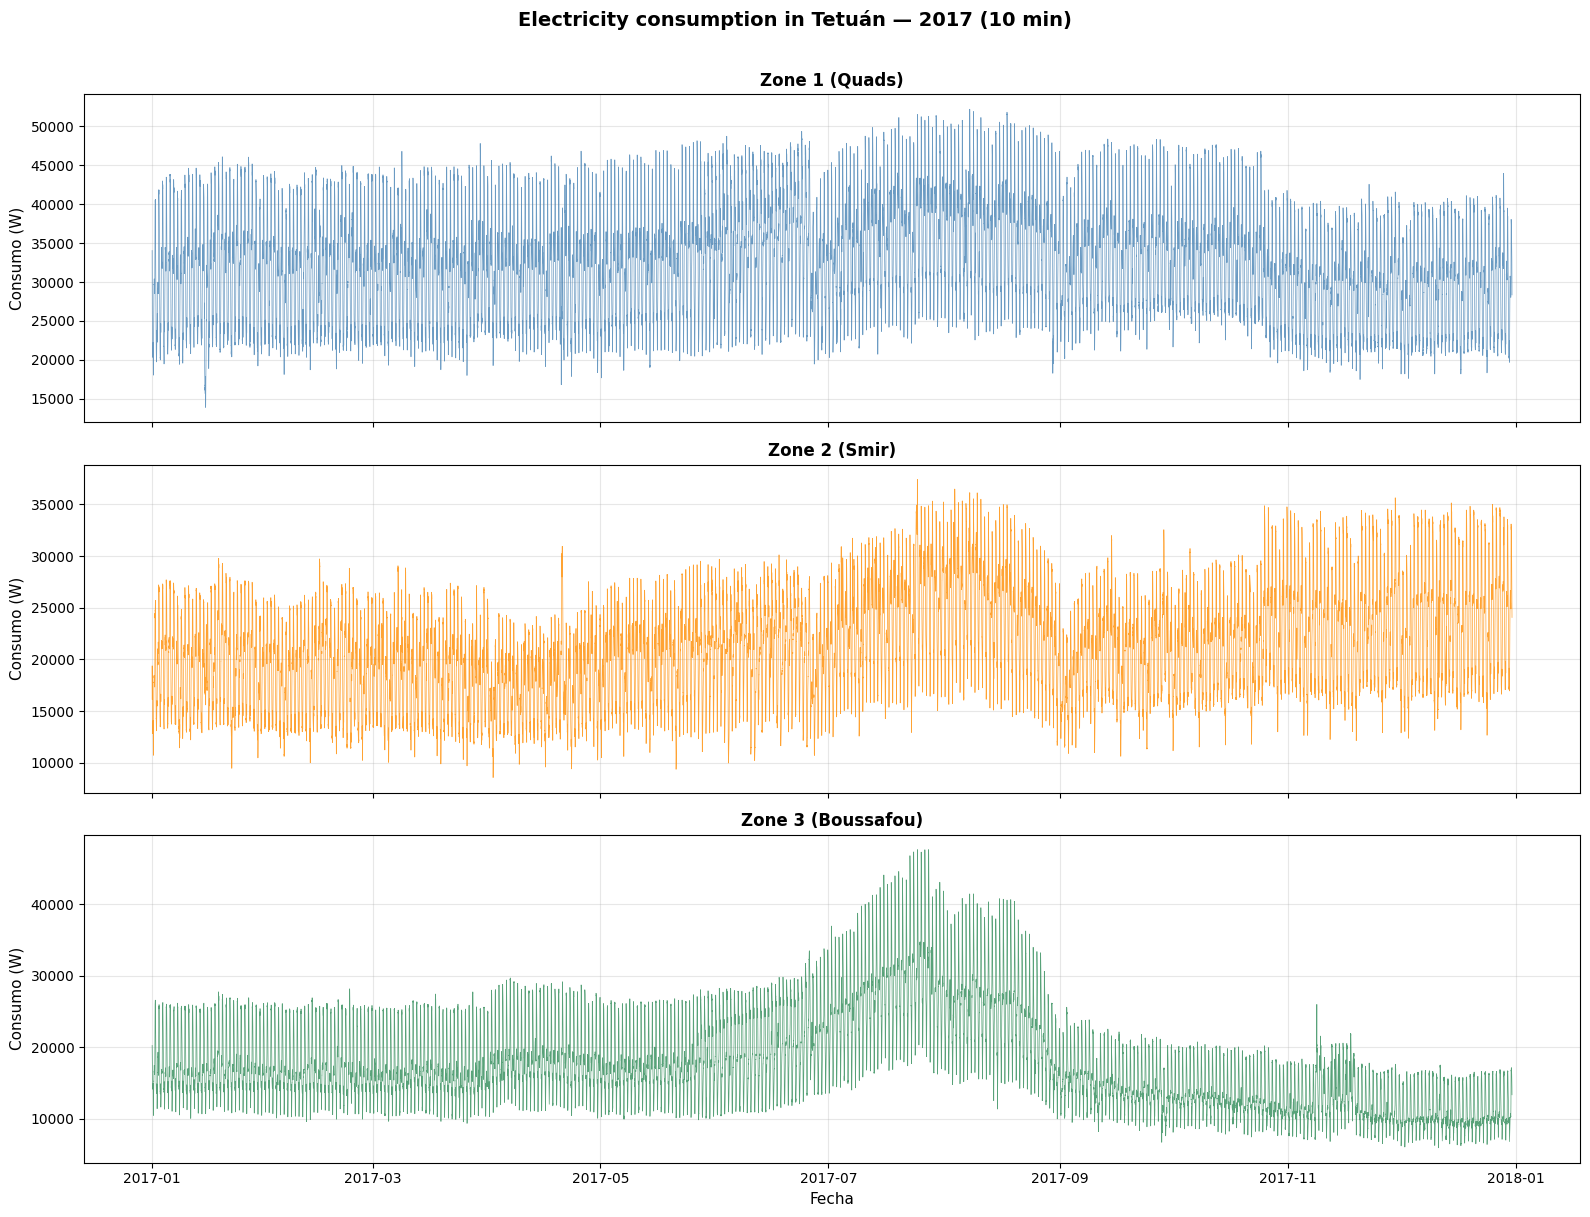

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

zones = ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
colors = ['steelblue', 'darkorange', 'seagreen']
labels = ['Zone 1 (Quads)', 'Zone 2 (Smir)', 'Zone 3 (Boussafou)']

for ax, zone, color, label in zip(axes, zones, colors, labels):
    ax.plot(df.index, df[zone], color=color, alpha=0.8, linewidth=0.5)
    ax.set_ylabel('Consumo (W)', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha', fontsize=11)
plt.suptitle('Electricity consumption in Tetuán — 2017 (10 min)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

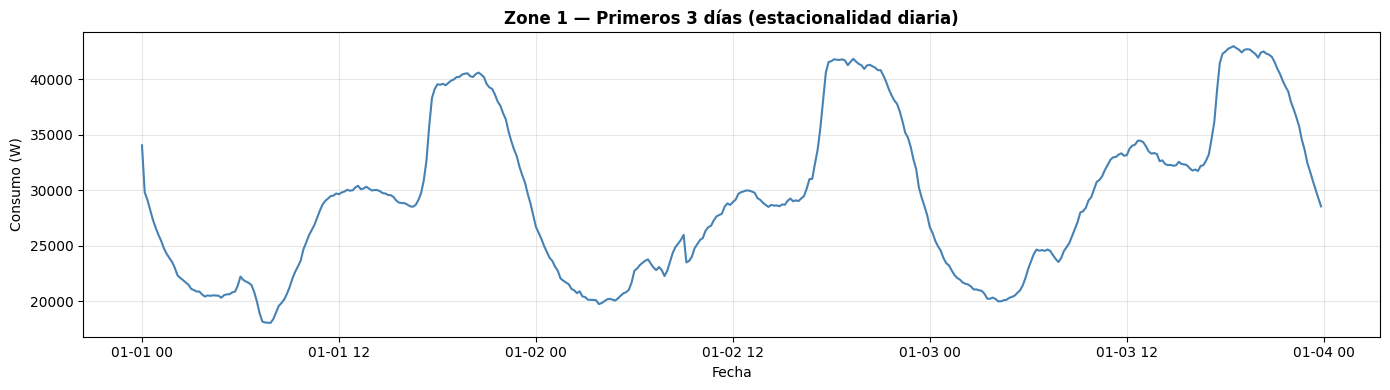

In [12]:
ts_zone1 = df['PowerConsumption_Zone1']
first_3_days = ts_zone1.iloc[:432]  

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(first_3_days.index, first_3_days.values, color='steelblue')
ax.set_title('Zone 1 — Primeros 3 días (estacionalidad diaria)', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Consumo (W)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

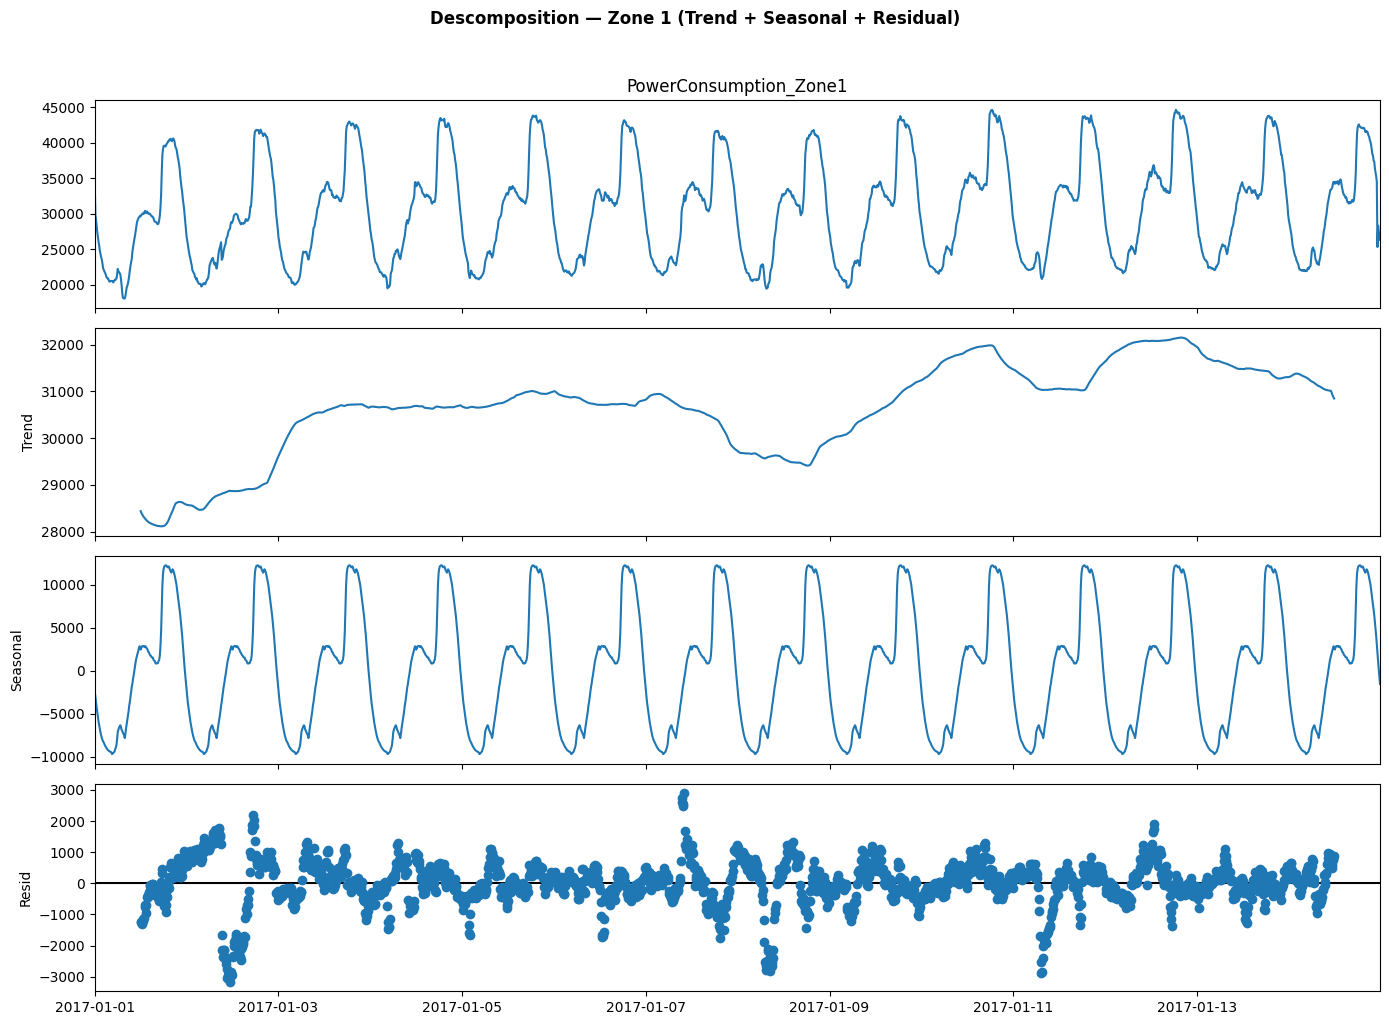

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_zone1.iloc[:2016], model='additive', period=144)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Descomposition — Zone 1 (Trend + Seasonal + Residual)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [2]:
result_adf = adfuller(train)
print(f'P-value ADF: {result_adf[1]}')

P-value ADF: 0.0


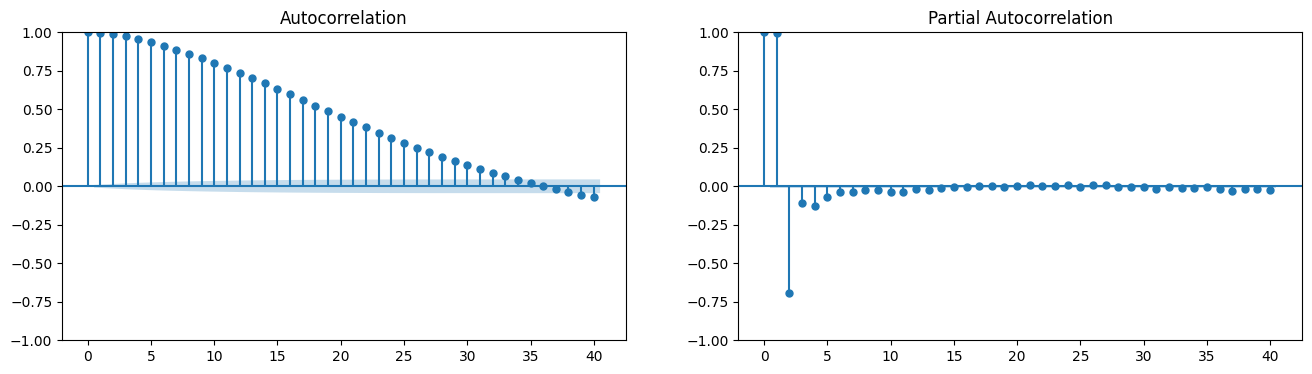

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(train, lags=40, ax=axes[0])
plot_pacf(train, lags=40, ax=axes[1])
plt.show()

In [8]:
import warnings
warnings.filterwarnings("ignore") # To keep the output clean

# Explicitly test specific combinations to meet the project requirements
combos_to_show = [(2,0,0), (3,0,2), (1,0,1), (2,0,2)]

best_aic = float("inf")
best_order = None

print("Evaluating specific combinations for the report:")
for order in combos_to_show:
    try:
        m = ARIMA(train, order=order).fit()
        print(f"ARIMA{order} -> AIC: {m.aic:.2f}")
        
        # Identify the model with the lowest AIC
        if m.aic < best_aic:
            best_aic = m.aic
            best_order = order
    except:
        print(f"ARIMA{order} -> Failed to converge")
        continue

print(f"\nBest combination selected: ARIMA{best_order} with AIC: {best_aic:.2f}")

best_model = ARIMA(train, order=best_order).fit()

Evaluating specific combinations for the report:
ARIMA(2, 0, 0) -> AIC: 787938.75
ARIMA(3, 0, 2) -> AIC: 785953.43
ARIMA(1, 0, 1) -> AIC: 800314.02
ARIMA(2, 0, 2) -> AIC: 786049.06

Best combination selected: ARIMA(3, 0, 2) with AIC: 785953.43


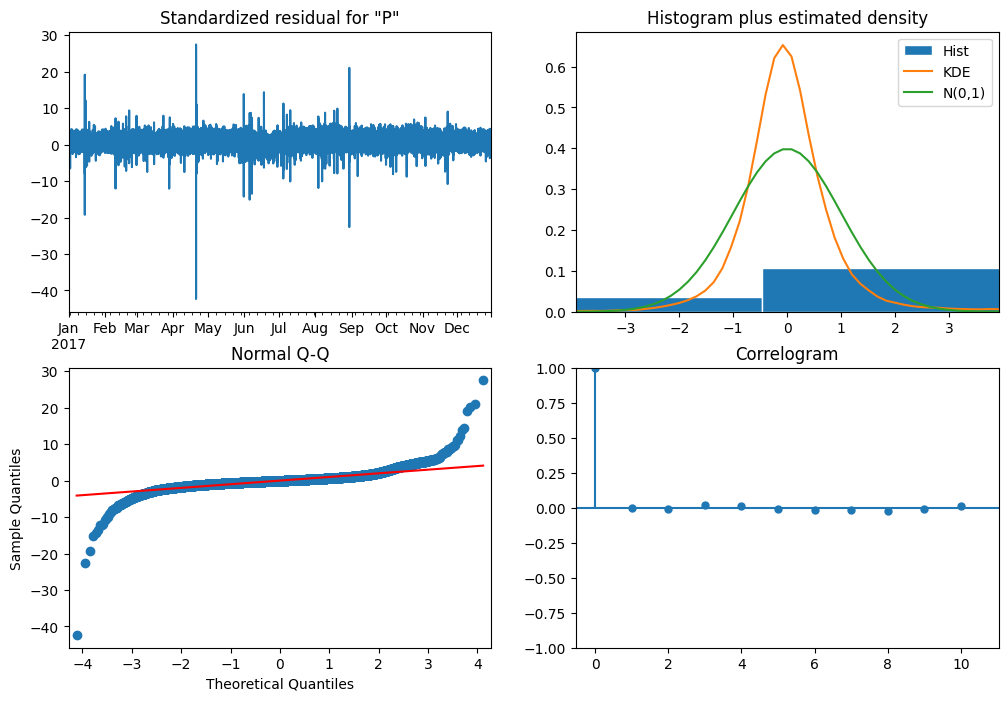

Ljung-Box test on residuals:
      lb_stat     lb_pvalue
1    0.261602  6.090219e-01
2    1.731371  4.207630e-01
3   23.921780  2.593709e-05
4   29.940850  5.032034e-06
5   36.050383  9.280229e-07
6   44.605302  5.606108e-08
7   58.736531  2.697054e-10
8   83.052880  1.185368e-14
9   89.985795  1.638790e-15
10  97.401690  1.802262e-16


In [9]:
best_model.plot_diagnostics(figsize=(12,8))
plt.show()

print("Ljung-Box test on residuals:")
print(acorr_ljungbox(best_model.resid, np.arange(1, 11, 1)))

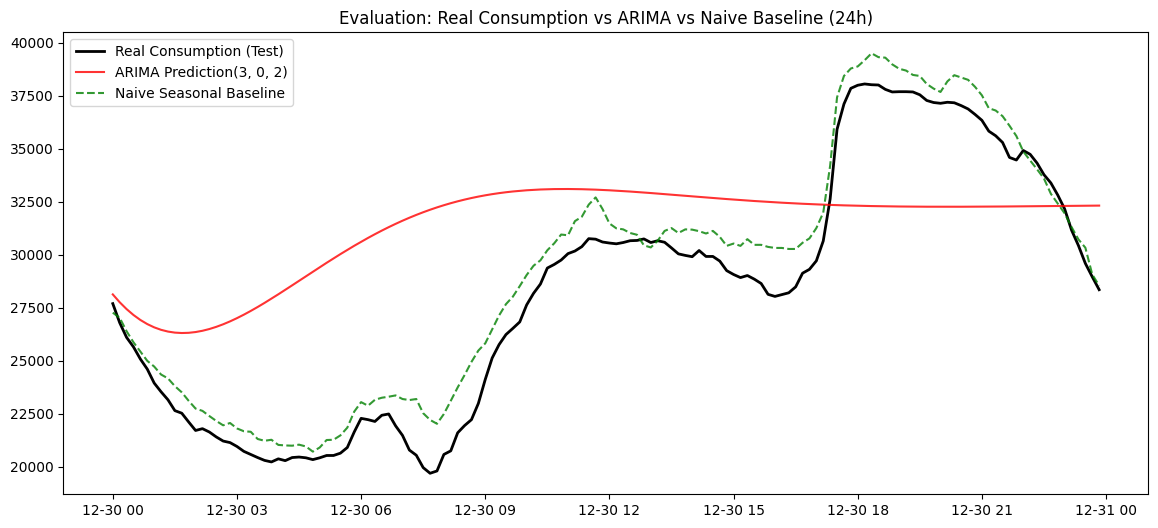

Naive Baseline Error (MSE): 1582230.19
ARIMA Model Error (MSE):  33892467.78


In [10]:
# 1. ARIMA model prediction
arima_predictions = best_model.forecast(steps=records_per_day)

# 2. Naive Seasonal Baseline: copy the exact records from the previous 24 hours
naive_baseline = train.iloc[-records_per_day:].values

# 3. Comparative plot
plt.figure(figsize=(14,6))

plt.plot(test.index, test.values,
         label='Real Consumption (Test)',
         color='black',
         linewidth=2)

plt.plot(test.index, arima_predictions,
         label=f'ARIMA Prediction{best_order}',
         color='red',
         alpha=0.8)

plt.plot(test.index, naive_baseline,
         label='Naive Seasonal Baseline',
         color='green',
         linestyle='--',
         alpha=0.8)

plt.title("Evaluation: Real Consumption vs ARIMA vs Naive Baseline (24h)")
plt.legend()
plt.show()

# 4. Error calculation (MSE) to see which model performs better
print(f"Naive Baseline Error (MSE): {mean_squared_error(test, naive_baseline):.2f}")
print(f"ARIMA Model Error (MSE):  {mean_squared_error(test, arima_predictions):.2f}")